# The Law of Total Probability

## Learning Objectives

By the end of this notebook you will be able to:

1. Define a **partition** of the sample space and explain why it's useful.
2. State and apply the **law of total probability** to compute $P(B)$ by case analysis.
3. Combine total probability with Bayes' theorem to solve multi-stage inference problems.
4. Apply the **law of total expectation** $E[X] = \sum_i E[X|A_i] P(A_i)$ (preview for Module 02).

## Prerequisites

- [01_sample_spaces.ipynb](01_sample_spaces.ipynb) — axioms, sample spaces
- [03_conditional_probability.ipynb](03_conditional_probability.ipynb) — conditional probability, Bayes' theorem

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)
        if not self.has_latex:
            print("⚠ LaTeX not found — MathTex will fall back to Text().")

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()

---

## 1. Partitions

The law of total probability is about **breaking a hard probability into easy pieces**. The key concept is a partition.

> **Definition 4.1 (Partition).** Events $A_1, A_2, \dots, A_n$ form a *partition* of $\Omega$ if:
> 1. They are **mutually exclusive**: $A_i \cap A_j = \varnothing$ for $i \neq j$.
> 2. They are **exhaustive**: $A_1 \cup A_2 \cup \cdots \cup A_n = \Omega$.

In other words, every outcome belongs to exactly one $A_i$. The partition "slices" the sample space into non-overlapping pieces that together cover everything.

**Examples of partitions:**
- $\{A, A^c\}$ — the simplest partition (any event and its complement).
- Die roll: $\{\{1,2\}, \{3,4\}, \{5,6\}\}$ — three pairs.
- Medical: $\{\text{disease}, \text{no disease}\}$.
- Factory: $\{\text{machine A}, \text{machine B}, \text{machine C}\}$ — which machine produced the item.

---

## 2. The Law of Total Probability

> **Theorem 4.2 (Law of total probability).** If $A_1, A_2, \dots, A_n$ is a partition of $\Omega$ with $P(A_i) > 0$ for all $i$, then for any event $B$:
>
> $$P(B) = \sum_{i=1}^{n} P(B \mid A_i) \, P(A_i)$$

**Proof.** Since $\{A_i\}$ is a partition, $B = (B \cap A_1) \cup (B \cap A_2) \cup \cdots \cup (B \cap A_n)$, and these pieces are disjoint. By Axiom 3:

$$P(B) = \sum_{i=1}^n P(B \cap A_i) = \sum_{i=1}^n P(B|A_i) \, P(A_i) \quad \square$$

**Intuition:** We don't know $P(B)$ directly, but we *do* know $P(B)$ within each "scenario" $A_i$. Total probability reconstructs $P(B)$ as a weighted average of these scenario-specific probabilities.

### Connection to Bayes' theorem

This is exactly the denominator in Bayes' theorem! Recall:

$$P(A_k \mid B) = \frac{P(B \mid A_k) \, P(A_k)}{\sum_{i=1}^n P(B \mid A_i) \, P(A_i)}$$

The law of total probability computes the $P(B)$ that Bayes' theorem needs.

The animation below visualises how the partition slices event $B$ into pieces, each weighted by the partition cell's probability.

In [2]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C, COLORS

Manim Community v0.18.1

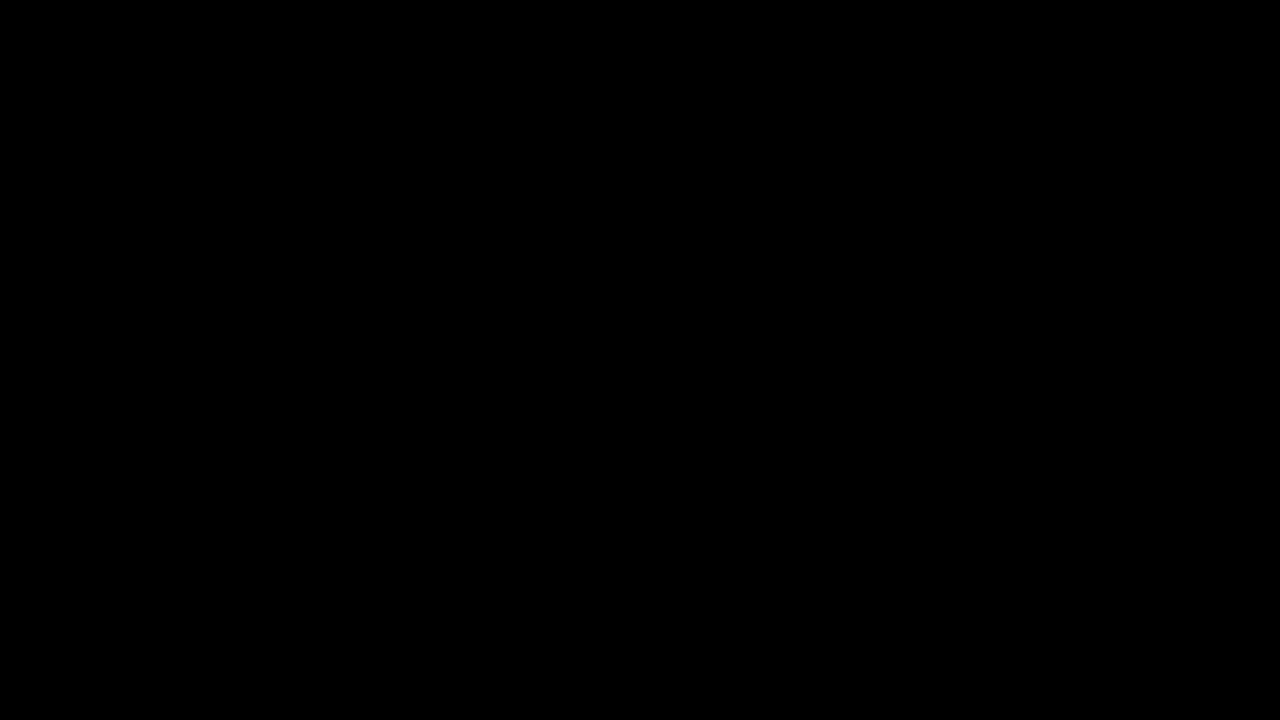

In [ ]:
%%manim -qm -v WARNING TotalProbabilityPartition


class TotalProbabilityPartition(Scene):
    """Visualise the law of total probability as a partitioned sample space."""

    def construct(self):
        title = Text("Law of Total Probability", font_size=30).to_edge(UP)
        self.play(Write(title))

        # Sample space as a wide rectangle
        omega = Rectangle(width=10, height=4, color=WHITE, stroke_width=2).shift(
            DOWN * 0.3
        )
        omega_lbl = math_text(r"\Omega", font_size=22).move_to(
            omega.get_corner(UL) + DR * 0.3
        )
        self.play(Create(omega), Write(omega_lbl))

        # Partition into 3 vertical strips: A1, A2, A3
        colors = [C.SALMON, C.PERIWINKLE, C.EMERALD]
        widths = [3.0, 4.0, 3.0]  # proportional to P(Ai)
        labels_text = [r"A_1", r"A_2", r"A_3"]
        prob_text = ["0.3", "0.4", "0.3"]

        x_start = omega.get_left()[0]
        strips = []
        for i, (w, col, lbl, p) in enumerate(
            zip(widths, colors, labels_text, prob_text)
        ):
            strip = Rectangle(
                width=w, height=4, color=col, fill_opacity=0.15, stroke_width=1.5
            )
            strip.move_to([x_start + w / 2, omega.get_center()[1], 0])
            label = math_text(lbl, font_size=24, color=col).move_to(
                strip.get_top() + DOWN * 0.3
            )
            plbl = Text(f"P = {p}", font_size=16, color=col).move_to(
                strip.get_bottom() + UP * 0.3
            )
            self.play(FadeIn(strip), Write(label), Write(plbl), run_time=0.5)
            strips.append(strip)
            x_start += w

        self.wait(0.5)

        # Event B as a horizontal band across all strips
        b_rect = Rectangle(
            width=10, height=1.5, color=C.GOLD, fill_opacity=0.3, stroke_width=2.5
        ).move_to(omega.get_center() + UP * 0.3)
        b_label = math_text(r"B", font_size=28, color=C.GOLD).next_to(
            b_rect, RIGHT, buff=0.2
        )
        self.play(FadeIn(b_rect), Write(b_label))
        self.wait(0.5)

        # Show the formula
        formula = math_text(
            r"P(B) = P(B|A_1)P(A_1) + P(B|A_2)P(A_2) + P(B|A_3)P(A_3)",
            font_size=22,
            color=C.GOLD,
        ).to_edge(DOWN, buff=0.3)
        self.play(Write(formula))
        self.wait(2)

The partition $\{A_1, A_2, A_3\}$ divides $\Omega$ into vertical strips. Event $B$ (the horizontal band) crosses all three strips. The law of total probability says: compute $P(B)$ within each strip, weight by the strip's probability, and add.

---

## 3. Worked Example: Defective Products from Multiple Machines

A factory has three machines producing items:

| Machine | Share of production | Defect rate |
|---------|---------------------|-------------|
| $A_1$   | 30%                 | 2%          |
| $A_2$   | 45%                 | 3%          |
| $A_3$   | 25%                 | 5%          |

**Question 1:** What is the overall defect rate $P(D)$?

$$P(D) = P(D|A_1)P(A_1) + P(D|A_2)P(A_2) + P(D|A_3)P(A_3)$$

**Question 2:** A defective item is found. Which machine most likely produced it? (This is Bayes' theorem.)

$$P(A_k | D) = \frac{P(D|A_k) P(A_k)}{P(D)}$$

In [ ]:
# Machine data
machines = ["A1", "A2", "A3"]
share = np.array([0.30, 0.45, 0.25])  # P(Ai)
defect_rate = np.array([0.02, 0.03, 0.05])  # P(D|Ai)

# Question 1: Law of total probability
p_defect = np.sum(defect_rate * share)
print(f"Overall defect rate P(D) = {p_defect:.4f} = {p_defect:.2%}")
print()

# Question 2: Bayes' theorem for each machine
posterior = (defect_rate * share) / p_defect
for m, s, d, p in zip(machines, share, defect_rate, posterior):
    print(f"  P({m}|D) = P(D|{m})·P({m}) / P(D) = {d}×{s} / {p_defect:.4f} = {p:.4f}")

print(f"\nMost likely source: {machines[np.argmax(posterior)]} ({posterior.max():.1%})")

Overall defect rate P(D) = 0.0320 = 3.20%

  P(A1|D) = P(D|A1)·P(A1) / P(D) = 0.02×0.3 / 0.0320 = 0.1875
  P(A2|D) = P(D|A2)·P(A2) / P(D) = 0.03×0.45 / 0.0320 = 0.4219
  P(A3|D) = P(D|A3)·P(A3) / P(D) = 0.05×0.25 / 0.0320 = 0.3906

Most likely source: A2 (42.2%)


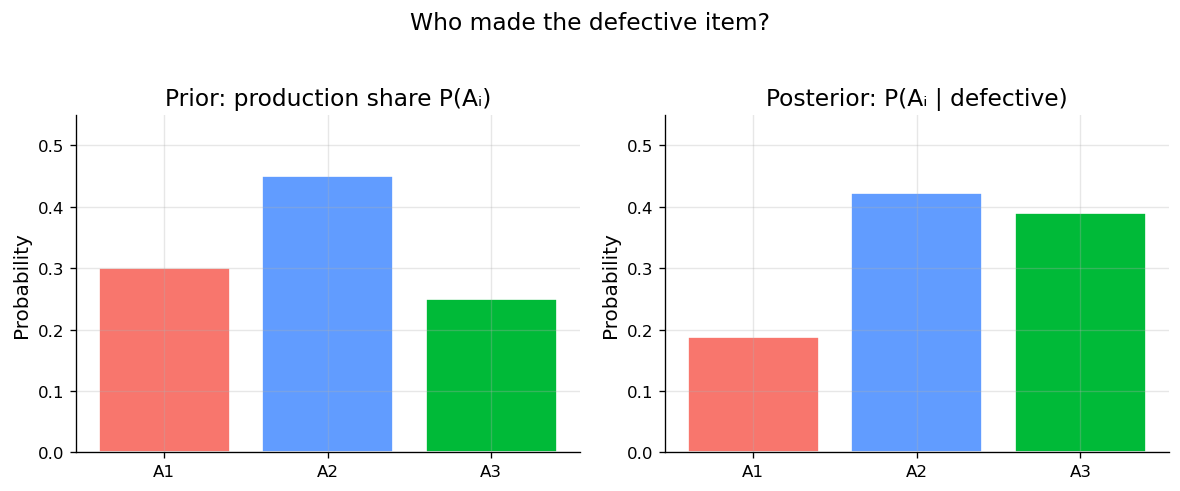

In [ ]:
# Visualise: prior vs posterior
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(machines, share, color=["#F8766D", "#619CFF", "#00BA38"], edgecolor="white")
axes[0].set_title("Prior: production share P(Aᵢ)")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 0.55)

axes[1].bar(
    machines, posterior, color=["#F8766D", "#619CFF", "#00BA38"], edgecolor="white"
)
axes[1].set_title("Posterior: P(Aᵢ | defective)")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 0.55)

plt.suptitle("Who made the defective item?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Machine $A_2$ produces the most items (45%) and has a moderate defect rate (3%), so it's the most likely source of any given defect. Machine $A_3$ has the highest defect rate (5%) but a smaller share of production, so it comes second. This is the interplay between **prior** (production share) and **likelihood** (defect rate) that Bayes' theorem captures.

---

## 4. Worked Example: Multi-Stage Diagnostics

Let's revisit the medical screening from the previous notebook, but now with **two tests**.

Recall: prevalence = 1%, sensitivity = 80%, false positive rate = 9.6%.

A patient tests positive on the **first** test. We showed that $P(D|+_1) \approx 0.078$.

Now they take a **second, independent** test and it's also positive. What is $P(D|+_1, +_2)$?

**Strategy:** Use the posterior from test 1 as the **prior** for test 2. This is **sequential Bayesian updating** — a preview of the Bayesian inference module.

$$P(D|+_1, +_2) = \frac{P(+_2|D) \cdot P(D|+_1)}{P(+_2|D) \cdot P(D|+_1) + P(+_2|\bar{D}) \cdot P(\bar{D}|+_1)}$$

In [ ]:
# Test parameters
sens = 0.80  # P(+|D)
fpr = 0.096  # P(+|healthy)
prevalence = 0.01

# After test 1
p_d_after_1 = (sens * prevalence) / (sens * prevalence + fpr * (1 - prevalence))
print(f"After test 1: P(D|+₁)     = {p_d_after_1:.4f}")

# After test 2 (use posterior from test 1 as prior)
prior_2 = p_d_after_1
p_d_after_2 = (sens * prior_2) / (sens * prior_2 + fpr * (1 - prior_2))
print(f"After test 2: P(D|+₁,+₂)  = {p_d_after_2:.4f}")

# After a hypothetical test 3
prior_3 = p_d_after_2
p_d_after_3 = (sens * prior_3) / (sens * prior_3 + fpr * (1 - prior_3))
print(f"After test 3: P(D|+₁,+₂,+₃) = {p_d_after_3:.4f}")

After test 1: P(D|+₁)     = 0.0776
After test 2: P(D|+₁,+₂)  = 0.4123
After test 3: P(D|+₁,+₂,+₃) = 0.8539


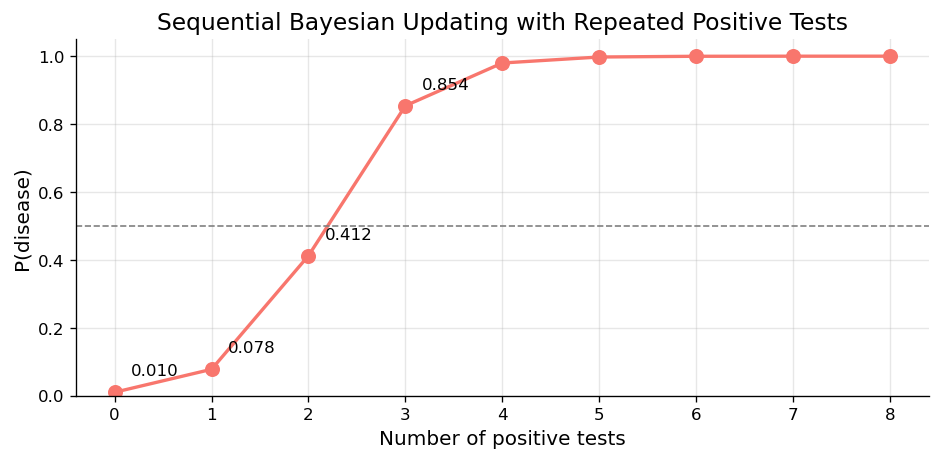

In [ ]:
# Visualise sequential updating
priors = [prevalence]
current = prevalence
for _ in range(8):
    current = (sens * current) / (sens * current + fpr * (1 - current))
    priors.append(current)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(priors)), priors, "o-", color="#F8766D", linewidth=2, markersize=8)
ax.set_xlabel("Number of positive tests")
ax.set_ylabel("P(disease)")
ax.set_title("Sequential Bayesian Updating with Repeated Positive Tests")
ax.set_xticks(range(len(priors)))
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)

# Annotate key points
for i, p in enumerate(priors[:4]):
    ax.annotate(
        f"{p:.3f}", (i, p), textcoords="offset points", xytext=(10, 10), fontsize=10
    )

plt.tight_layout()
plt.show()

Each positive test shifts the probability upward. After one test: ~8%. After two: ~42%. After three: ~86%. The initially low base rate is gradually overwhelmed by accumulating evidence. This is the essence of **Bayesian reasoning** — we'll explore it deeply in Module 07.

---

## 5. Law of Total Expectation (Preview)

The law of total probability has an important analogue for **expected values** (which we formalise in Module 02). If $\{A_i\}$ is a partition:

$$E[X] = \sum_{i} E[X \mid A_i] \, P(A_i)$$

This says: the overall average is the weighted average of the within-group averages. We use this constantly in statistics — for example, the overall mean height of a population is the weighted average of mean heights by gender, age group, or any other partition.

### Quick example

A tutoring centre has two groups: beginners (60% of students, average score 65) and advanced (40%, average score 85). The overall average score is:

$$E[\text{score}] = 65 \times 0.6 + 85 \times 0.4 = 39 + 34 = 73$$

In [ ]:
# Law of total expectation
groups = ["Beginners", "Advanced"]
proportions = [0.6, 0.4]
means = [65, 85]

overall_mean = sum(p * m for p, m in zip(proportions, means))
print(
    f"E[score] = {means[0]}×{proportions[0]} + {means[1]}×{proportions[1]} = {overall_mean}"
)

# Verify with simulation
rng = np.random.default_rng(42)
n = 10_000
is_advanced = rng.random(n) < 0.4
scores = np.where(
    is_advanced,
    rng.normal(85, 10, n),  # advanced: mean 85, sd 10
    rng.normal(65, 12, n),  # beginners: mean 65, sd 12
)
print(f"Simulated mean: {scores.mean():.1f} (n = {n:,})")

E[score] = 65×0.6 + 85×0.4 = 73.0
Simulated mean: 73.3 (n = 10,000)


---

## Exercises

**Exercise 4.1 (Total probability).** A student takes one of three routes to class: route A (40% of the time, 5% chance of being late), route B (35%, 10% late), route C (25%, 15% late). What is $P(\text{late})$?

**Exercise 4.2 (Bayes + total probability).** Using the data from Exercise 4.1: the student arrives late. Which route did they most likely take?

**Exercise 4.3 (Quality control).** Supplier X provides 70% of parts (1% defective). Supplier Y provides 30% (3% defective). A defective part is found. What is the probability it came from supplier Y?

**Exercise 4.4 (Sequential updating).** A disease has 5% prevalence. A test has 95% sensitivity and 10% false positive rate. Compute $P(D)$ after 1, 2, and 3 positive tests. How many positive tests are needed for $P(D) > 0.99$?

**Exercise 4.5 (Total expectation).** An insurance company has three risk classes: low (50%, average claim \$200), medium (35%, \$500), high (15%, \$1200). What is the expected claim amount?

**Exercise 4.6 (Challenge — Simpson's paradox).** Hospital A has a higher survival rate than Hospital B for *each* disease severity level (mild, severe). Yet Hospital B has a higher *overall* survival rate. Construct a concrete numerical example showing this is possible. Explain using the law of total probability.

---

## Key Takeaways

1. A **partition** $\{A_1, \dots, A_n\}$ divides $\Omega$ into non-overlapping, exhaustive pieces.
2. The **law of total probability** $P(B) = \sum_i P(B|A_i) P(A_i)$ computes $P(B)$ by decomposing it into cases — this is the denominator of Bayes' theorem.
3. Bayes' theorem + total probability = **full inference machinery**: given evidence $B$, we can compute $P(A_k|B)$ for each scenario.
4. **Sequential updating**: applying Bayes repeatedly with each new piece of evidence — a preview of Bayesian inference (Module 07).
5. The **law of total expectation** generalises the same idea to averages.

**Next:** [05_random_variables.ipynb](05_random_variables.ipynb) — Random variables, expectation, and variance — the bridge to named distributions.

In [9]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-05-35.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@12-10-14.gif
  ✓ media/gifs/CoinFlipConvergence@2026-03-19@13-42-51.gif
  ✓ media/gifs/ConditionalProbVenn@2026-03-19@13-48-05.gif
  ✓ media/gifs/DiceHistogram@2026-03-19@13-43-26.gif
  ✓ media/gifs/PascalTriangle@2026-03-19@13-44-25.gif
  ✓ media/gifs/TotalProbabilityPartition@2026-03-19@13-50-32.gif
  ✓ media/gifs/TreeDiagram@2026-03-19@13-44-07.gif
  ✓ media/gifs/TotalProbabilityPartition_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
